In [1]:
import google.auth
credentials, PROJECT_ID= google.auth.default()
print(credentials)
print(PROJECT_ID)

anbc-hcb-dev


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import numpy as np

In [3]:
from google.cloud import bigquery
client = bigquery.Client()

sql = """
select *
from `anbc-hcb-dev.cm_medicaid_hcb_dev.a534354_komodo_Feb_2024_June_2023_embeddings` 
"""
kmdo = client.query(sql).to_dataframe() 
kmdo.head()

,emb0,emb1,emb2,emb3,emb4,emb5,emb6,emb7,emb8,emb9,...,emb247,emb248,emb249,emb250,emb251,emb252,emb253,emb254,emb255,individual_id
0,0.439080,0.080255,-0.477010,-0.155486,0.195565,0.742208,-0.672388,-0.544305,0.137382,-0.392130,...,0.328378,-0.062854,-0.254263,-0.914905,0.830371,-0.355027,-0.040956,-0.063636,-0.841125,520108287
1,-0.439103,-0.073759,-0.510107,-0.345004,-0.076379,0.814164,-0.500342,-0.704165,0.575125,-0.102492,...,0.397844,-0.107834,-0.341100,-0.870074,0.667846,0.036254,0.322128,-0.567949,-0.157303,480514883
2,-0.445019,-0.279461,-0.722022,-0.134213,-0.077474,0.729250,-0.962365,-0.842522,0.630165,-0.477751,...,0.458297,0.217868,-0.486143,-1.024280,0.800492,0.390249,-0.100219,-0.965269,-0.080289,451266735
3,0.022217,0.434583,-0.707025,-0.555725,0.107678,-0.109800,-1.112773,-1.509479,0.042009,0.020355,...,-0.382142,0.396206,0.794209,-0.173562,1.147137,-0.493957,0.459321,-0.355242,0.432667,590049875
4,-0.008771,-0.441163,-0.222724,-0.246640,-0.598746,0.433860,-0.261189,-0.558725,0.387139,-0.098656,...,-0.033886,-0.242124,0.380713,-0.442306,1.019184,-0.390995,0.293174,-0.675926,-0.274718,480217146


In [4]:
sql = """
select *
from `anbc-hcb-dev.cm_medicaid_hcb_dev.Medicaid_June_2023_member` 
"""
mem = client.query(sql).to_dataframe() 
mem.head()

,asdb_member_key,asdb_plan_key,asdb_plan_nm,asdb_elig_dt,coa_population_category,coa_population_group
0,480496377,48,VA,2023-06-01,DD,ABD
1,480317391,48,VA,2023-06-01,DD,ABD
2,480439373,48,VA,2023-06-01,DD,ABD
3,480316790,48,VA,2023-06-01,DD,ABD
4,480280276,48,VA,2023-06-01,DD,ABD


In [5]:
kmdo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2575882 entries, 0 to 2575881
Columns: 257 entries, emb0 to individual_id
dtypes: Int64(1), float64(256)
memory usage: 4.9 GB


In [6]:
kmdo.describe()

,emb0,emb1,emb2,emb3,emb4,emb5,emb6,emb7,emb8,emb9,...,emb247,emb248,emb249,emb250,emb251,emb252,emb253,emb254,emb255,individual_id
count,2.575882e+06,2.575882e+06,2.575882e+06,2.575882e+06,2.575882e+06,2.575882e+06,2.575882e+06,2.575882e+06,2.575882e+06,2.575882e+06,...,2.575882e+06,2.575882e+06,2.575882e+06,2.575882e+06,2.575882e+06,2.575882e+06,2.575882e+06,2.575882e+06,2.575882e+06,2575882.0
mean,-1.063717e-01,-3.141704e-01,-6.249239e-01,-4.254983e-02,-1.796511e-01,6.939990e-01,-6.808317e-01,-6.300101e-01,3.980532e-01,-4.317341e-01,...,2.147803e-01,1.359783e-01,-4.160736e-01,-7.302565e-01,1.001600e+00,2.875021e-02,-3.490821e-02,-5.801447e-01,-4.401877e-01,386036994.670337
std,3.688322e-01,3.443815e-01,3.362748e-01,3.219162e-01,3.422009e-01,4.260911e-01,3.490037e-01,4.415149e-01,3.044510e-01,3.079169e-01,...,3.734049e-01,3.084037e-01,3.597518e-01,4.058741e-01,2.936207e-01,4.615548e-01,4.558779e-01,3.424570e-01,4.516342e-01,155766820.363627
min,-1.872243e+00,-2.088967e+00,-1.978813e+00,-1.603575e+00,-1.955281e+00,-1.611272e+00,-2.309932e+00,-2.643075e+00,-1.168329e+00,-1.837485e+00,...,-2.244984e+00,-1.577331e+00,-2.075815e+00,-2.289048e+00,-1.253212e+00,-2.185220e+00,-1.705450e+00,-2.097685e+00,-2.496762e+00,71093269.0
25%,-3.594426e-01,-5.526200e-01,-8.680667e-01,-2.651291e-01,-4.141035e-01,4.261450e-01,-9.265136e-01,-9.442483e-01,1.958556e-01,-6.362520e-01,...,-2.308800e-02,-7.822395e-02,-6.665152e-01,-1.022954e+00,8.162480e-01,-2.973179e-01,-3.555523e-01,-8.132455e-01,-7.126991e-01,351531421.5
50%,-1.165837e-01,-3.345147e-01,-6.809080e-01,-3.730642e-02,-2.030208e-01,7.073583e-01,-7.029034e-01,-6.550117e-01,4.004330e-01,-4.509568e-01,...,2.267958e-01,1.304548e-01,-4.281104e-01,-7.624781e-01,1.004249e+00,4.186950e-02,-7.125624e-02,-6.082569e-01,-4.612717e-01,450757594.0
75%,1.346836e-01,-1.019036e-01,-4.243859e-01,1.894525e-01,3.233016e-02,9.813163e-01,-4.561411e-01,-3.402290e-01,6.015321e-01,-2.543963e-01,...,4.700013e-01,3.453652e-01,-1.788245e-01,-4.669665e-01,1.188596e+00,3.691394e-01,2.513305e-01,-3.759542e-01,-2.045432e-01,480571065.75
max,2.218686e+00,2.034804e+00,1.335244e+00,1.243200e+00,2.305148e+00,2.685492e+00,1.305643e+00,1.847407e+00,2.151554e+00,1.679810e+00,...,2.008598e+00,1.513192e+00,1.763515e+00,1.686864e+00,2.539749e+00,1.762753e+00,2.225772e+00,1.536968e+00,4.177351e+00,600037559.0


In [7]:
mem.describe()

,asdb_member_key,asdb_plan_key
count,2848383.0,2848383.0
mean,388507616.521713,38.742848
std,154952724.151431,15.56389
min,71093269.0,7.0
25%,351551505.0,35.0
50%,450865908.0,45.0
75%,480616228.5,48.0
max,600035508.0,60.0


In [8]:
mem.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2848383 entries, 0 to 2848382
Data columns (total 6 columns):
 #   Column                   Dtype 
---  ------                   ----- 
 0   asdb_member_key          Int64 
 1   asdb_plan_key            Int64 
 2   asdb_plan_nm             object
 3   asdb_elig_dt             dbdate
 4   coa_population_category  object
 5   coa_population_group     object
dtypes: Int64(2), dbdate(1), object(3)
memory usage: 135.8+ MB


In [9]:
print(mem['coa_population_group'].value_counts())

TANF/CHIP    1566888
Expansion     731116
ABD           158875
BH            118451
LTSS           81785
Dual Elig      77420
Other          67490
Dual Int       46358
Name: coa_population_group, dtype: int64


In [10]:
mem = mem.rename(columns={"asdb_member_key": "individual_id"})

In [11]:
kmdo_mem = mem.merge(kmdo, on='individual_id', how='left')
kmdo_mem = kmdo_mem.assign(embed_type = 'komodo_integrated')
kmdo_mem.fillna(value = 0, inplace = True)

In [12]:
sql = """
select *
from `anbc-hcb-dev.cm_medicaid_hcb_dev.Medicaid_June_2023_outcomes_revised` 
"""
outcomes = client.query(sql).to_dataframe() 
outcomes.head()

,asdb_member_key,acute_ip_flag,sum_acute_ip_admits,sum_acute_calc_los,non_acute_ip_flag,sum_non_acute_ip_admits,maternity_ip_flag,sum_maternity_ip_admits,sum_ed_visits,ed_flag,sum_avoidable,sum_unnecessary,sum_preventable
0,520492042,0,0.0,0,0,0.0,0,0.0,0,0,0,0,0
1,71877926,0,0.0,0,1,1.0,0,0.0,0,0,0,0,0
2,281691075,0,0.0,0,0,0.0,0,0.0,0,0,0,0,0
3,480469230,0,0.0,0,0,0.0,0,0.0,0,0,0,0,0
4,460895564,0,0.0,0,0,0.0,0,0.0,0,0,0,0,0


In [13]:
outcomes = outcomes.rename(columns={"asdb_member_key": "individual_id"})
kmdo_outcome = kmdo_mem.merge(outcomes, on='individual_id', how='left')

In [14]:
from google.cloud import bigquery
client = bigquery.Client()

sql = """
select *
from `anbc-hcb-dev.cm_medicaid_hcb_dev.Medicaid_June_2023_outcome_months` 
"""
outcome_tenure = client.query(sql).to_dataframe() 
outcome_tenure.head()

,asdb_member_key,asdb_plan_key,asdb_plan_nm,asdb_elig_dt,coa_population_category,coa_population_group,outcome_tenure
0,480272777,48,VA,2023-06-01,DD,ABD,6
1,480213704,48,VA,2023-06-01,DD,ABD,6
2,480238631,48,VA,2023-06-01,DD,ABD,6
3,480582723,48,VA,2023-06-01,DD,ABD,6
4,480176857,48,VA,2023-06-01,DD,ABD,6


In [15]:
outcome_tenure = outcome_tenure.rename(columns={"asdb_member_key": "individual_id"})
kmdo_outcome = kmdo_outcome.merge(outcome_tenure, on='individual_id', how='left')

In [16]:
kmdo_outcome = kmdo_outcome.loc[kmdo_outcome['outcome_tenure'].isin([6,])]

In [17]:
kmdo_outcome.shape

(2274967, 281)

In [19]:
print(kmdo_outcome['coa_population_group_x'].value_counts())

TANF/CHIP    1239344
Expansion     574219
ABD           141225
BH             89517
LTSS           71326
Dual Elig      62792
Other          56303
Dual Int       40241
Name: coa_population_group_x, dtype: int64


In [20]:
#kmdo_outcome.fillna(value = 0, inplace = True)
kmdo_outcome.head()

,individual_id,asdb_plan_key_x,asdb_plan_nm_x,asdb_elig_dt_x,coa_population_category_x,coa_population_group_x,emb0,emb1,emb2,emb3,...,ed_flag,sum_avoidable,sum_unnecessary,sum_preventable,asdb_plan_key_y,asdb_plan_nm_y,asdb_elig_dt_y,coa_population_category_y,coa_population_group_y,outcome_tenure
0,480496377,48,VA,2023-06-01,DD,ABD,-0.215800,-0.803819,-0.683592,-0.181459,...,0,0,0,0,48,VA,2023-06-01,DD,ABD,6
1,480317391,48,VA,2023-06-01,DD,ABD,-0.579397,-0.827498,-0.518047,-0.248597,...,0,0,0,0,48,VA,2023-06-01,DD,ABD,6
2,480439373,48,VA,2023-06-01,DD,ABD,-0.234080,-0.361929,-0.644043,0.087198,...,0,0,0,0,48,VA,2023-06-01,DD,ABD,6
3,480316790,48,VA,2023-06-01,DD,ABD,-0.620917,-0.553905,-0.150488,0.069995,...,0,0,0,0,48,VA,2023-06-01,DD,ABD,6
4,480280276,48,VA,2023-06-01,DD,ABD,0.084072,-0.003385,-0.506918,-0.912890,...,0,0,0,0,48,VA,2023-06-01,DD,ABD,6


In [21]:
print(kmdo_outcome['acute_ip_flag'].value_counts())

0    2236407
1      38560
Name: acute_ip_flag, dtype: Int64


In [22]:
kmdo_outcome = kmdo_outcome.set_index('individual_id')

In [23]:
#split dataset in features and target variable
X = kmdo_outcome.iloc[:, 5:261] # Features
y = kmdo_outcome.loc[:, 'acute_ip_flag'] # Target variable
X.head()

,emb0,emb1,emb2,emb3,emb4,emb5,emb6,emb7,emb8,emb9,...,emb246,emb247,emb248,emb249,emb250,emb251,emb252,emb253,emb254,emb255
individual_id,,,,,,,,,,,,,,,,,,,,,
480496377,-0.215800,-0.803819,-0.683592,-0.181459,-0.349996,0.863326,-0.756493,-0.703543,0.580766,-0.494291,...,0.438906,0.209351,0.161548,-0.546932,-0.746221,0.988175,-0.104153,0.032598,-0.372578,-0.723293
480317391,-0.579397,-0.827498,-0.518047,-0.248597,-0.219182,0.846339,-0.849919,-0.289182,0.334397,-0.437150,...,0.587415,-0.045649,0.066199,-0.991269,-0.996345,0.954494,0.083925,0.409516,-0.746750,-0.182793
480439373,-0.234080,-0.361929,-0.644043,0.087198,-0.351456,1.218282,-0.760346,-0.510615,0.533147,-0.912987,...,0.044363,0.079645,0.312615,-0.754629,-0.641178,0.910781,0.458381,-0.655047,-0.854195,-0.693588
480316790,-0.620917,-0.553905,-0.150488,0.069995,-0.155134,0.620722,0.075114,0.188820,0.348037,-0.448313,...,-0.186291,0.314058,-0.105467,-0.527681,-0.666013,0.566444,0.166222,0.197361,-0.428165,0.351788
480280276,0.084072,-0.003385,-0.506918,-0.912890,-0.215087,0.511924,0.570814,0.091947,-0.150027,-0.011420,...,-0.224258,0.006922,-0.641616,0.279538,-0.324054,0.619110,-0.379859,0.335250,-0.288411,-0.171576


In [24]:
# split X and y into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=20)

In [25]:
# import the class
from sklearn.linear_model import LogisticRegression

# instantiate the model (using the default parameters)
logreg = LogisticRegression(random_state=16)

# fit the model with data
logreg.fit(X_train, y_train)

LogisticRegression(random_state=16)

In [26]:
y_pred = logreg.predict(X_test)
y_pred = y_test.to_frame()
y_pred = pd.DataFrame(y_pred)
y_pred.head()
y_pred.shape

(568742, 1)

In [27]:
threshold = 0.3

y_predict_prob =logreg.predict_proba(X_test)[:, 1]
y_predict_lab = ((logreg.predict_proba(X_test)[:, 1])>= threshold).astype(int)

y_pred['y_predict_prob'] = y_predict_prob
y_pred['y_predict_class'] = y_predict_lab
y_pred.head()
#y_id = y_train.iloc[0]
pd.crosstab(y_pred['acute_ip_flag'], y_pred['y_predict_class'])

y_predict_class,0,1
acute_ip_flag,,
0,557774,1306
1,8883,779


In [28]:
from joblib import dump, load
dump(logreg, 'Medicaid_IP_embeddings_only_logreg.joblib') 
#logreg = load('Medicaid_IP_embeddings_only_logreg.joblib')

['Medicaid_IP_embeddings_only_logreg.joblib']

In [29]:
# import the metrics class
from sklearn import metrics

cnf_matrix = metrics.confusion_matrix(y_test, y_predict_lab)
cnf_matrix

array([[557774,   1306],
       [  8883,    779]])

Text(0.5, 427.9555555555555, 'Predicted label')

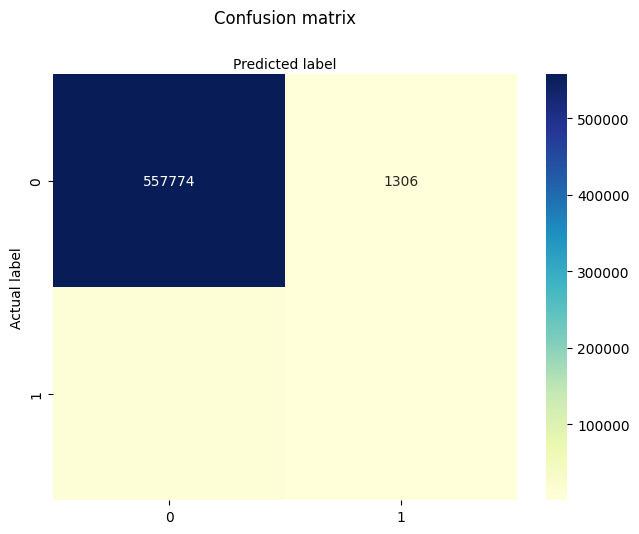

In [30]:
# import required modules
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

class_names=[0,1] # name  of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
# create heatmap
sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')

#Text(0.5,257.44,'Predicted label');

In [31]:
from sklearn.metrics import classification_report
target_names = ['without IP', 'with IP']
print(classification_report(y_test, y_predict_lab, target_names=target_names))

              precision    recall  f1-score   support

  without IP       0.98      1.00      0.99    559080
     with IP       0.37      0.08      0.13      9662

    accuracy                           0.98    568742
   macro avg       0.68      0.54      0.56    568742
weighted avg       0.97      0.98      0.98    568742



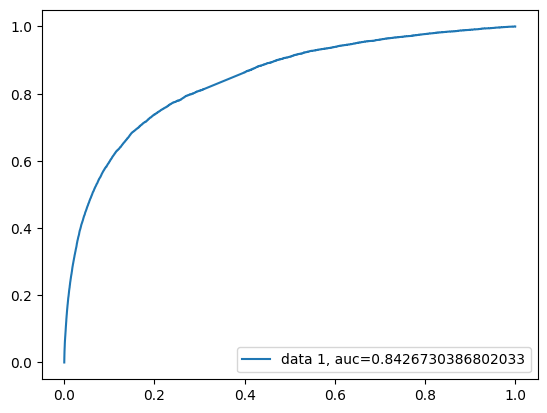

In [32]:
y_pred_proba = logreg.predict_proba(X_test)[::,1]
fpr, tpr, _ = metrics.roc_curve(y_test,  y_pred_proba)
auc = metrics.roc_auc_score(y_test, y_pred_proba)
plt.plot(fpr,tpr,label="data 1, auc="+str(auc))
plt.legend(loc=4)
plt.show()

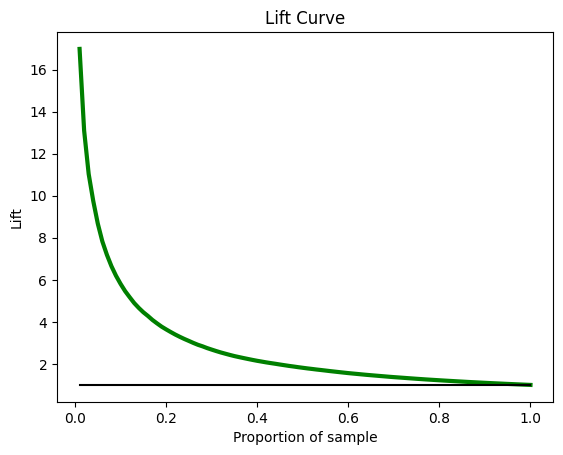

In [33]:
# Function that plots a Lift Curve using the real label values of a dataset and the probability predictions of a Machine Learning Algorithm/model
# @Params:
# y_val: real labels of the data
# y_pred: probability predictions for such data
# step: how big we want the steps in the percentiles to be

# imports
import numpy as np
import pandas as pd

def plot_lift_curve(y_val, y_pred, step=0.01):
    
    #Define an auxiliar dataframe to plot the curve
    aux_lift = pd.DataFrame()
    #Create a real and predicted column for our new DataFrame and assign values
    aux_lift['real'] = y_val
    aux_lift['predicted'] = y_pred
    #Order the values for the predicted probability column:
    aux_lift.sort_values('predicted',ascending=False,inplace=True)
    
    #Create the values that will go into the X axis of our plot
    x_val = np.arange(step,1+step,step)
    #Calculate the ratio of ones in our data
    ratio_ones = aux_lift['real'].sum() / len(aux_lift)
    #Create an empty vector with the values that will go on the Y axis our our plot
    y_v = []
    
    #Calculate for each x value its correspondent y value
    for x in x_val:
        num_data = int(np.ceil(x*len(aux_lift))) #The ceil function returns the closest integer bigger than our number 
        data_here = aux_lift.iloc[:num_data,:]   # ie. np.ceil(1.4) = 2
        ratio_ones_here = data_here['real'].sum()/len(data_here)
        y_v.append(ratio_ones_here / ratio_ones)
           
   #Plot the figure
    fig, axis = plt.subplots()
    fig.figsize = (40,40)
    axis.plot(x_val, y_v, 'g-', linewidth = 3, markersize = 5)
    axis.plot(x_val, np.ones(len(x_val)), 'k-')
    axis.set_xlabel('Proportion of sample')
    axis.set_ylabel('Lift')
    plt.title('Lift Curve')
    plt.show()
    
plot_lift_curve(y_test, y_pred_proba, step=0.01)

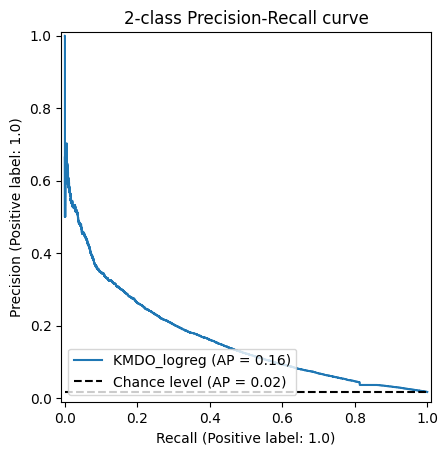

In [34]:
from sklearn.metrics import PrecisionRecallDisplay

display = PrecisionRecallDisplay.from_estimator(
    logreg, X_test, y_test, name="KMDO_logreg", plot_chance_level=True
)
_ = display.ax_.set_title("2-class Precision-Recall curve")

In [35]:
def lift_chart(X,actual_target,model):
    avg_tgt = actual_target.sum()/len(actual_target)
    df_data = X.copy()
    X_data = df_data.copy()
    df_data['Actual'] = actual_target
    df_data['Predict']= model.predict(X_data)
    y_Prob = pd.DataFrame(model.predict_proba(X_data))
    df_data['Prob_1']=list(y_Prob[1])
    df_data.sort_values(by=['Prob_1'],ascending=False,inplace=True)
    df_data.reset_index(drop=True,inplace=True)
    df_data['Percentile']=pd.qcut(df_data.index,100,labels=False)
    output_df = pd.DataFrame()
    grouped = df_data.groupby('Percentile',as_index=False)
    output_df['Max_Scr']=grouped.max().Prob_1
    output_df['Min_Scr']=grouped.min().Prob_1
    output_df['Actual']=grouped.sum().Actual
    output_df['Total']=grouped.count().Actual
    output_df["Population_perc"] = (output_df["Total"]/len(actual_target))*100
    output_df['Per_Events'] = (output_df['Actual']/output_df['Actual'].sum())*100
    output_df['Gain_Percentage'] = output_df.Per_Events.cumsum()
    output_df["Cumulative_Population"] = output_df.Population_perc.cumsum()
    output_df["Lift"] = output_df["Gain_Percentage"]/output_df["Cumulative_Population"]
    return output_df

In [36]:
lift_chart(X_test, y_test, logreg)

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,0.698134,0.202605,1641,5688,1.000102,16.984061,16.984061,1.000102,16.982329
1,0.202604,0.137878,890,5687,0.999926,9.211343,26.195405,2.000028,13.097518
2,0.137873,0.106062,667,5688,1.000102,6.903333,33.098737,3.000130,11.032434
3,0.106058,0.085722,571,5687,0.999926,5.90975,39.008487,4.000056,9.751985
4,0.085717,0.071598,421,5688,1.000102,4.357276,43.365763,5.000158,8.672878
...,...,...,...,...,...,...,...,...,...
95,0.001572,0.001497,13,5688,1.000102,0.134548,99.668806,95.999944,1.038217
96,0.001496,0.001414,9,5687,0.999926,0.093148,99.761954,96.999870,1.028475
97,0.001414,0.001314,8,5688,1.000102,0.082799,99.844753,97.999972,1.018824
98,0.001314,0.001176,7,5687,0.999926,0.072449,99.917201,98.999898,1.009266


In [37]:
def lift_chart(X,actual_target,model):
    avg_tgt = actual_target.sum()/len(actual_target)
    df_data = X.copy()
    X_data = df_data.copy()
    df_data['Actual'] = actual_target
    df_data['Predict']= model.predict(X_data)
    y_Prob = pd.DataFrame(model.predict_proba(X_data))
    df_data['Prob_1']=list(y_Prob[1])
    df_data.sort_values(by=['Prob_1'],ascending=False,inplace=True)
    df_data.reset_index(drop=True,inplace=True)
    df_data['Decile']=pd.qcut(df_data.index,10,labels=False)
    output_df = pd.DataFrame()
    grouped = df_data.groupby('Decile',as_index=False)
    output_df['Max_Scr']=grouped.max().Prob_1
    output_df['Min_Scr']=grouped.min().Prob_1
    output_df['Actual']=grouped.sum().Actual
    output_df['Total']=grouped.count().Actual
    output_df["Population_perc"] = (output_df["Total"]/len(actual_target))*100
    output_df['Per_Events'] = (output_df['Actual']/output_df['Actual'].sum())*100
    output_df['Gain_Percentage'] = output_df.Per_Events.cumsum()
    output_df["Cumulative_Population"] = output_df.Population_perc.cumsum()
    output_df["Lift"] = output_df["Gain_Percentage"]/output_df["Cumulative_Population"]
    return output_df

In [38]:
lift_chart(X_test, y_test, logreg)

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,0.698134,0.037076,5611,56875,10.000141,58.072863,58.072863,10.000141,5.807205
1,0.037075,0.016550,1427,56874,9.999965,14.769199,72.842062,20.000105,3.642084
2,0.016550,0.009593,732,56874,9.999965,7.576071,80.418133,30.000070,2.680598
3,0.009593,0.008823,527,56874,9.999965,5.454357,85.87249,40.000035,2.14681
4,0.008823,0.006004,471,56874,9.999965,4.874767,90.747257,50.000000,1.814945
5,0.006004,0.004316,288,56874,9.999965,2.980749,93.728007,59.999965,1.562134
6,0.004316,0.003235,217,56874,9.999965,2.245912,95.973918,69.999930,1.371057
7,0.003235,0.002486,167,56874,9.999965,1.728421,97.702339,79.999895,1.221281
8,0.002486,0.001884,125,56874,9.999965,1.293728,98.996067,89.999859,1.099958
9,0.001884,0.000124,97,56875,10.000141,1.003933,100.0,100.000000,1.0


In [39]:
sql = """
select *
from `anbc-hcb-dev.cm_medicaid_hcb_dev.Medicaid_June_2023_tenure` 
"""
tenure = client.query(sql).to_dataframe() 
tenure.head()

,asdb_member_key,asdb_plan_key,asdb_plan_nm,asdb_elig_dt,coa_population_category,coa_population_group,tenure
0,72302035,7,MCP,2023-06-01,DD,ABD,13
1,72681434,7,MCP,2023-06-01,DD,ABD,13
2,72096067,7,MCP,2023-06-01,DD,ABD,13
3,72094013,7,MCP,2023-06-01,DD,ABD,13
4,71226635,7,MCP,2023-06-01,DD,ABD,13


In [40]:
tenure = tenure.rename(columns={"asdb_member_key": "individual_id"})
tenure = tenure.set_index('individual_id')

In [41]:
pd.crosstab(tenure['tenure'], tenure['coa_population_group'])

coa_population_group,ABD,BH,Dual Elig,Dual Int,Expansion,LTSS,Other,TANF/CHIP
tenure,,,,,,,,
0,1685,6575,1711,1003,9932,1424,1143,27216
1,1446,5464,1374,1139,9245,1467,1122,22299
2,1584,4703,1327,1461,11862,1447,1016,23053
3,1546,4671,1500,864,11206,1451,1087,22922
4,1573,4202,1782,850,14719,1537,1069,23926
5,4360,3981,3511,1254,38691,1398,739,59359
6,1480,3646,571,421,9631,1033,867,25653
7,1436,3017,570,559,9412,1191,896,26271
8,1380,5286,632,1035,8594,1175,1039,23517


In [42]:
tenure.head()

,asdb_plan_key,asdb_plan_nm,asdb_elig_dt,coa_population_category,coa_population_group,tenure
individual_id,,,,,,
72302035,7,MCP,2023-06-01,DD,ABD,13
72681434,7,MCP,2023-06-01,DD,ABD,13
72096067,7,MCP,2023-06-01,DD,ABD,13
72094013,7,MCP,2023-06-01,DD,ABD,13
71226635,7,MCP,2023-06-01,DD,ABD,13


In [43]:
df_out = pd.merge(y_pred, tenure, how = 'left',left_index = True, right_index = True)

In [44]:
df_out.shape
df_out.head()

,acute_ip_flag,y_predict_prob,y_predict_class,asdb_plan_key,asdb_plan_nm,asdb_elig_dt,coa_population_category,coa_population_group,tenure
individual_id,,,,,,,,,
351750797,0,0.001350,0,35,IL,2023-06-01,TANF,TANF/CHIP,13
480247750,0,0.001221,0,48,VA,2023-06-01,TANF,TANF/CHIP,13
351952899,0,0.008823,0,35,IL,2023-06-01,Expansion,Expansion,13
440649895,0,0.001266,0,44,WV,2023-06-01,TANF,TANF/CHIP,13
480440190,0,0.002904,0,48,VA,2023-06-01,TANF,TANF/CHIP,13


In [45]:
print("% admitted post 6 months ABD: ", df_out[df_out['coa_population_group']=='ABD']['acute_ip_flag'].mean()*100)
print("% admitted post 6 months BH: ", df_out[df_out['coa_population_group']=='BH']['acute_ip_flag'].mean()*100)
print("% admitted post 6 months Dual Elig: ", df_out[df_out['coa_population_group']=='Dual Elig']['acute_ip_flag'].mean()*100)
print("% admitted post 6 months Dual Int: ", df_out[df_out['coa_population_group']=='Dual Int']['acute_ip_flag'].mean()*100)
print("% admitted post 6 months Exp: ", df_out[df_out['coa_population_group']=='Expansion']['acute_ip_flag'].mean()*100)
print("% admitted post 6 months LTSS: ", df_out[df_out['coa_population_group']=='LTSS']['acute_ip_flag'].mean()*100)
print("% admitted post 6 months Other: ", df_out[df_out['coa_population_group']=='Other']['acute_ip_flag'].mean()*100)
print("% admitted post 6 months TANF/CHIP: ", df_out[df_out['coa_population_group']=='TANF/CHIP']['acute_ip_flag'].mean()*100)

% admitted post 6 months ABD:  3.725815990312315
% admitted post 6 months BH:  2.3329326387961355
% admitted post 6 months Dual Elig:  5.324617630259567
% admitted post 6 months Dual Int:  6.029353431178104
% admitted post 6 months Exp:  1.8798562954298603
% admitted post 6 months LTSS:  9.480570751790648
% admitted post 6 months Other:  0.5802844809284552
% admitted post 6 months TANF/CHIP:  0.6156262421592484


In [87]:
def lift_chart(df):
    avg_tgt = df['acute_ip_flag']/len(df['acute_ip_flag'])
    df_data = df.copy()
    df_data['Actual'] = df['acute_ip_flag']
    df_data['Predict'] = df['y_predict_class']
    df_data['Prob_1'] = df['y_predict_prob']
    df_data.sort_values(by=['Prob_1'],ascending=False,inplace=True)
    df_data.reset_index(drop=True,inplace=True)
    df_data['Decile']=pd.qcut(df_data.index,100,labels=False)
    output_df = pd.DataFrame()
    grouped = df_data.groupby('Decile',as_index=False)
    output_df['Max_Scr']=grouped.max().Prob_1
    output_df['Min_Scr']=grouped.min().Prob_1
    output_df['Actual']=grouped.sum().Actual
    output_df['Total']=grouped.count().Actual
    output_df["Population_perc"] = (output_df["Total"]/len(df['acute_ip_flag']))*100
    output_df['Per_Events'] = (output_df['Actual']/output_df['Actual'].sum())*100
    output_df['Gain_Percentage'] = output_df.Per_Events.cumsum()
    output_df["Cumulative_Population"] = output_df.Population_perc.cumsum()
    output_df["Lift"] = output_df["Gain_Percentage"]/output_df["Cumulative_Population"]
    return output_df    

In [88]:
lift_chart(df_out[df_out['coa_population_group'].isin(['ABD'])])

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,0.651313,0.318298,163,356,1.002563,12.320484,12.320484,1.002563,12.28899
1,0.318250,0.243774,102,355,0.999747,7.709751,20.030234,2.002309,10.003567
2,0.243630,0.196032,76,355,0.999747,5.74452,25.774754,3.002056,8.585701
3,0.195986,0.165666,62,355,0.999747,4.686319,30.461073,4.001802,7.611839
4,0.165544,0.140917,46,355,0.999747,3.476946,33.93802,5.001549,6.785502
...,...,...,...,...,...,...,...,...,...
95,0.001940,0.001806,0,355,0.999747,0.0,99.773243,95.998198,1.039324
96,0.001806,0.001673,0,355,0.999747,0.0,99.773243,96.997944,1.028612
97,0.001672,0.001501,0,355,0.999747,0.0,99.773243,97.997691,1.018118
98,0.001500,0.001291,2,355,0.999747,0.151172,99.924414,98.997437,1.009364


In [89]:
lift_chart(df_out[df_out['coa_population_group'].isin(['BH'])])

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,0.607953,0.231072,73,225,1.001736,13.931298,13.931298,1.001736,13.90715
1,0.230821,0.173300,40,225,1.001736,7.633588,21.564885,2.003473,10.763753
2,0.173273,0.135655,30,224,0.997284,5.725191,27.290076,3.000757,9.094398
3,0.135452,0.115139,22,225,1.001736,4.198473,31.48855,4.002493,7.867234
4,0.114947,0.099768,25,225,1.001736,4.770992,36.259542,5.004230,7.245779
...,...,...,...,...,...,...,...,...,...
95,0.002809,0.002611,1,224,0.997284,0.19084,99.618321,95.997507,1.037718
96,0.002610,0.002373,1,225,1.001736,0.19084,99.80916,96.999243,1.028968
97,0.002371,0.002106,0,224,0.997284,0.0,99.80916,97.996527,1.018497
98,0.002106,0.001767,0,225,1.001736,0.0,99.80916,98.998264,1.008191


In [90]:
lift_chart(df_out[df_out['coa_population_group'].isin(['Dual Elig'])])

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,0.579868,0.312402,47,158,1.002729,5.601907,5.601907,1.002729,5.586661
1,0.311496,0.256264,31,158,1.002729,3.694875,9.296782,2.005458,4.63574
2,0.255814,0.221816,35,157,0.996383,4.171633,13.468415,3.001840,4.486719
3,0.221647,0.193034,31,158,1.002729,3.694875,17.16329,4.004569,4.285926
4,0.192622,0.173654,29,157,0.996383,3.456496,20.619785,5.000952,4.123172
...,...,...,...,...,...,...,...,...,...
95,0.003927,0.003557,0,157,0.996383,0.0,99.165673,95.995431,1.033025
96,0.003553,0.003095,3,158,1.002729,0.357569,99.523242,96.998160,1.026032
97,0.003092,0.002657,2,157,0.996383,0.238379,99.761621,97.994542,1.018032
98,0.002657,0.002077,1,158,1.002729,0.11919,99.88081,98.997271,1.008925


In [91]:
lift_chart(df_out[df_out['coa_population_group'].isin(['Dual Int'])])

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,0.626815,0.345645,58,101,1.001587,9.539474,9.539474,1.001587,9.524362
1,0.345564,0.271750,33,101,1.001587,5.427632,14.967105,2.003173,7.471697
2,0.271499,0.231920,27,101,1.001587,4.440789,19.407895,3.004760,6.45905
3,0.231259,0.204168,31,101,1.001587,5.098684,24.506579,4.006347,6.116939
4,0.204056,0.182946,23,101,1.001587,3.782895,28.289474,5.007933,5.648932
...,...,...,...,...,...,...,...,...,...
95,0.003994,0.003595,0,101,1.001587,0.0,99.013158,95.993653,1.031455
96,0.003594,0.003085,1,101,1.001587,0.164474,99.177632,96.995240,1.0225
97,0.003082,0.002596,1,101,1.001587,0.164474,99.342105,97.996827,1.013728
98,0.002589,0.001797,3,101,1.001587,0.493421,99.835526,98.998413,1.008456


In [92]:
lift_chart(df_out[df_out['coa_population_group'].isin(['Expansion'])])

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,0.698134,0.191909,403,1437,1.000501,14.925926,14.925926,1.000501,14.918447
1,0.191899,0.131586,204,1436,0.999805,7.555556,22.481481,2.000306,11.239019
2,0.131547,0.102823,152,1436,0.999805,5.62963,28.111111,3.000111,9.370022
3,0.102817,0.084617,113,1437,1.000501,4.185185,32.296296,4.000613,8.072838
4,0.084597,0.072549,91,1436,0.999805,3.37037,35.666667,5.000418,7.132737
...,...,...,...,...,...,...,...,...,...
95,0.002233,0.002100,3,1436,0.999805,0.111111,99.444444,95.999387,1.035886
96,0.002100,0.001943,5,1437,1.000501,0.185185,99.62963,96.999889,1.027111
97,0.001943,0.001768,3,1436,0.999805,0.111111,99.740741,97.999694,1.017766
98,0.001767,0.001516,4,1436,0.999805,0.148148,99.888889,98.999499,1.008984


In [93]:
lift_chart(df_out[df_out['coa_population_group'].isin(['LTSS'])])

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,0.680661,0.400052,78,178,1.003891,4.640095,4.640095,1.003891,4.622108
1,0.399884,0.348186,56,177,0.998252,3.33135,7.971446,2.002143,3.981456
2,0.347567,0.316832,50,177,0.998252,2.97442,10.945866,3.000395,3.648142
3,0.316735,0.292121,39,178,1.003891,2.320048,13.265913,4.004286,3.312928
4,0.292109,0.270128,45,177,0.998252,2.676978,15.942891,5.002538,3.186961
...,...,...,...,...,...,...,...,...,...
95,0.008823,0.008445,13,177,0.998252,0.773349,99.286139,95.995714,1.034277
96,0.008442,0.006946,2,178,1.003891,0.118977,99.405116,96.999605,1.024799
97,0.006936,0.005248,4,177,0.998252,0.237954,99.64307,97.997857,1.016788
98,0.005246,0.003503,3,177,0.998252,0.178465,99.821535,98.996109,1.008338


In [94]:
lift_chart(df_out[df_out['coa_population_group'].isin(['Other'])])

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,0.451126,0.061702,21,142,1.004883,25.609756,25.609756,1.004883,25.485314
1,0.061683,0.042612,8,141,0.997806,9.756098,35.365854,2.002689,17.659183
2,0.042552,0.032892,3,141,0.997806,3.658537,39.02439,3.000495,13.005983
3,0.032835,0.027352,1,142,1.004883,1.219512,40.243902,4.005378,10.047466
4,0.027307,0.023919,1,141,0.997806,1.219512,41.463415,5.003184,8.287405
...,...,...,...,...,...,...,...,...,...
95,0.001460,0.001395,0,141,0.997806,0.0,100.0,95.994622,1.041725
96,0.001394,0.001326,0,142,1.004883,0.0,100.0,96.999505,1.030933
97,0.001326,0.001250,0,141,0.997806,0.0,100.0,97.997311,1.020436
98,0.001249,0.001132,0,141,0.997806,0.0,100.0,98.995117,1.010151


In [95]:
lift_chart(df_out[df_out['coa_population_group'].isin(['TANF/CHIP'])])

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,0.615394,0.063320,354,3095,1.000191,18.582677,18.582677,1.000191,18.579135
1,0.063313,0.039508,145,3094,0.999868,7.611549,26.194226,2.000058,13.096732
2,0.039493,0.029767,77,3095,1.000191,4.041995,30.23622,3.000249,10.077904
3,0.029766,0.024256,74,3094,0.999868,3.884514,34.120735,4.000116,8.529936
4,0.024255,0.020614,59,3095,1.000191,3.097113,37.217848,5.000307,7.443113
...,...,...,...,...,...,...,...,...,...
95,0.001427,0.001369,4,3094,0.999868,0.209974,99.317585,95.999884,1.034559
96,0.001369,0.001305,3,3094,0.999868,0.15748,99.475066,96.999751,1.025519
97,0.001305,0.001224,5,3095,1.000191,0.262467,99.737533,97.999942,1.017731
98,0.001224,0.001103,3,3094,0.999868,0.15748,99.895013,98.999809,1.009042


In [55]:
ABD = df_out.loc[df_out['coa_population_group'].isin(['ABD'])]
BH = df_out.loc[df_out['coa_population_group'].isin(['BH'])]
D_Elig = df_out.loc[df_out['coa_population_group'].isin(['Dual Elig'])]
D_Int = df_out.loc[df_out['coa_population_group'].isin(['Dual Int'])]
Exp = df_out.loc[df_out['coa_population_group'].isin(['Expansion'])]
LTSS = df_out.loc[df_out['coa_population_group'].isin(['LTSS'])]
Oth = df_out.loc[df_out['coa_population_group'].isin(['Other'])]
T_C = df_out.loc[df_out['coa_population_group'].isin(['TANF/CHIP'])]

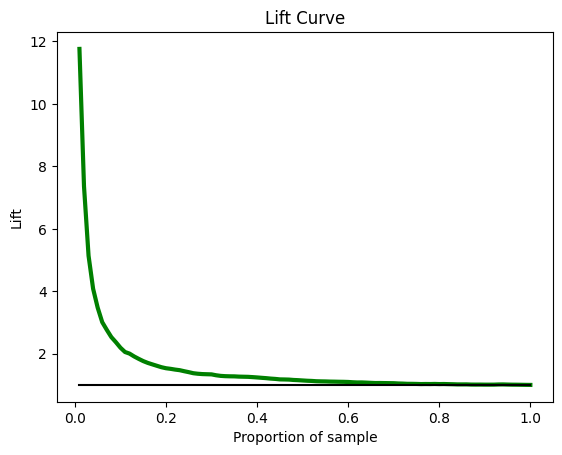

In [56]:
plot_lift_curve(ABD['acute_ip_flag'], ABD['y_predict_class'], step=0.01)

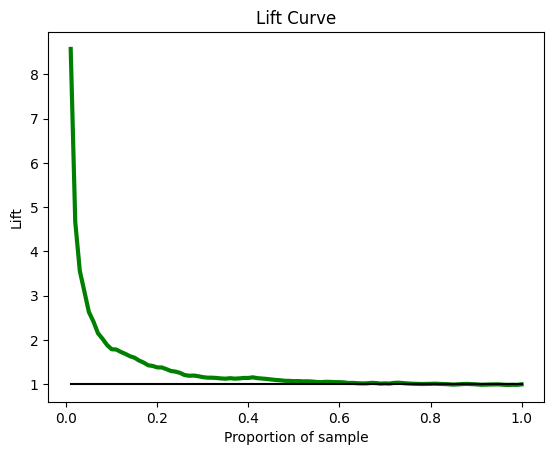

In [57]:
plot_lift_curve(BH['acute_ip_flag'], BH['y_predict_class'], step=0.01)

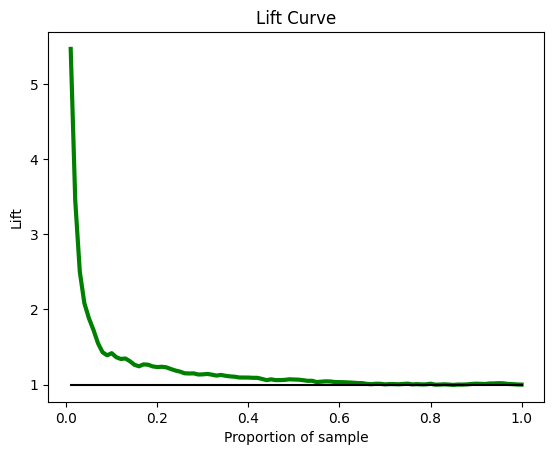

In [58]:
plot_lift_curve(D_Elig['acute_ip_flag'], D_Elig['y_predict_class'], step=0.01)

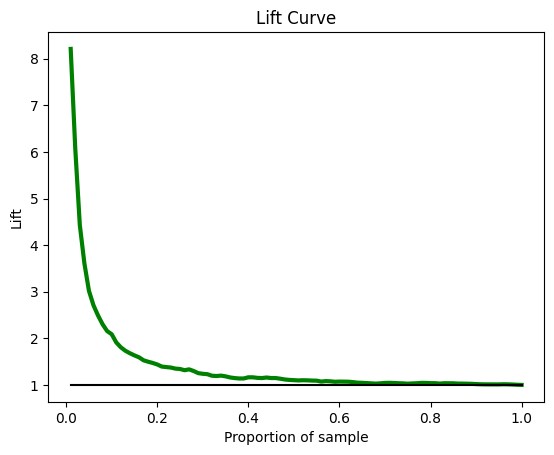

In [59]:
plot_lift_curve(D_Int['acute_ip_flag'], D_Int['y_predict_class'], step=0.01)

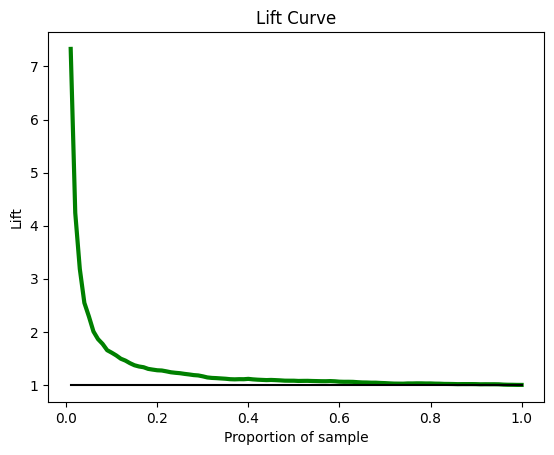

In [60]:
plot_lift_curve(Exp['acute_ip_flag'], Exp['y_predict_class'], step=0.01)

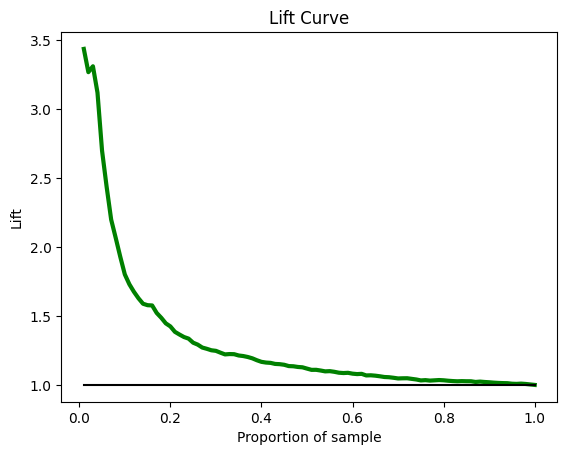

In [61]:
plot_lift_curve(LTSS['acute_ip_flag'], LTSS['y_predict_class'], step=0.01)

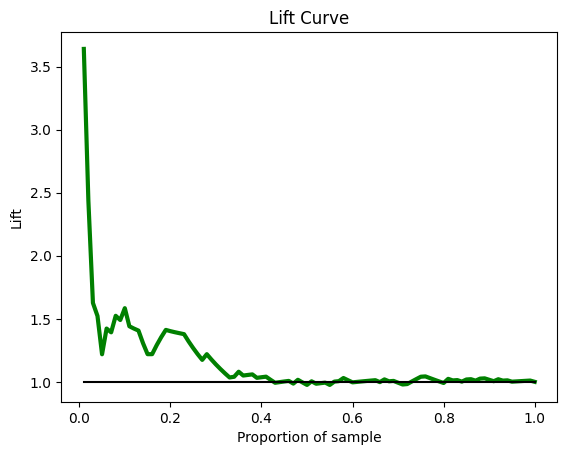

In [62]:
plot_lift_curve(Oth['acute_ip_flag'], Oth['y_predict_class'], step=0.01)

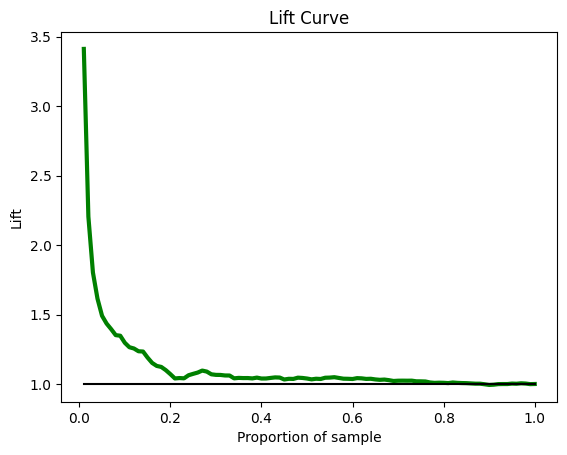

In [63]:
plot_lift_curve(T_C['acute_ip_flag'], T_C['y_predict_class'], step=0.01)

In [64]:
sql = """
select *
from `anbc-hcb-dev.cm_medicaid_hcb_dev.Medicaid_June_2023_embeddings` 
"""
mdcd = client.query(sql).to_dataframe() 
mdcd.head()

,emb0,emb1,emb2,emb3,emb4,emb5,emb6,emb7,emb8,emb9,...,emb247,emb248,emb249,emb250,emb251,emb252,emb253,emb254,emb255,individual_id
0,-0.687509,-0.655436,-1.111218,0.272748,-0.414622,1.165390,-1.000432,-1.328120,0.523168,0.178598,...,0.510278,0.236857,-0.440359,-0.947121,1.105275,0.048705,0.065849,-0.947952,-0.521748,71893071
1,-0.226355,-0.382465,-0.857254,0.197012,0.062982,0.814961,-0.439980,-0.828506,0.288742,-0.716885,...,0.583263,0.292798,-0.060565,-1.113949,1.302315,-0.405425,-0.247813,-0.364128,-0.459951,590022296
2,-0.925144,-0.408845,-0.663210,-0.247693,0.135970,1.169295,-0.759691,-0.965484,0.147179,-0.619127,...,0.663210,-0.219216,-0.542038,-1.148829,1.318734,-0.035962,-0.384528,-0.589371,-0.429543,72571242
3,-0.294320,-0.687069,-0.680449,-0.186953,-0.811478,0.108818,-0.163180,-0.205360,0.427813,-0.543561,...,-0.015166,-0.164913,0.113440,-0.299138,1.542696,-0.305206,0.183273,-0.550120,-0.551131,500333095
4,-0.510658,-0.549274,-0.567697,0.023068,-0.334395,0.247653,-0.326342,-0.195177,0.582522,-0.554075,...,0.485785,-0.275313,-0.549103,-1.021080,1.259082,0.236122,0.761901,-0.452693,-0.700391,72455291


In [65]:
mdcd.describe()

,emb0,emb1,emb2,emb3,emb4,emb5,emb6,emb7,emb8,emb9,...,emb247,emb248,emb249,emb250,emb251,emb252,emb253,emb254,emb255,individual_id
count,2.558703e+06,2.558703e+06,2.558703e+06,2.558703e+06,2.558703e+06,2.558703e+06,2.558703e+06,2.558703e+06,2.558703e+06,2.558703e+06,...,2.558703e+06,2.558703e+06,2.558703e+06,2.558703e+06,2.558703e+06,2.558703e+06,2.558703e+06,2.558703e+06,2.558703e+06,2558703.0
mean,-3.220146e-01,-4.365644e-01,-6.439361e-01,-1.425174e-02,-3.047745e-01,5.604255e-01,-5.873868e-01,-5.215223e-01,4.382489e-01,-5.023131e-01,...,1.844150e-01,6.286518e-02,-4.062001e-01,-7.305085e-01,1.141250e+00,4.915018e-03,7.257361e-02,-5.524878e-01,-4.773173e-01,386318760.211007
std,4.042996e-01,3.417458e-01,3.032332e-01,3.153879e-01,3.450923e-01,4.242368e-01,3.415329e-01,4.421241e-01,3.114789e-01,3.051915e-01,...,3.560601e-01,3.193698e-01,3.448445e-01,4.005657e-01,3.022495e-01,4.641422e-01,4.937936e-01,3.160821e-01,3.738650e-01,155481544.734168
min,-2.077059e+00,-1.791311e+00,-1.942421e+00,-1.644251e+00,-1.783396e+00,-1.765455e+00,-2.279972e+00,-2.157682e+00,-1.341166e+00,-2.084338e+00,...,-2.277879e+00,-1.452608e+00,-2.073822e+00,-2.507611e+00,-1.375809e+00,-2.474765e+00,-1.689979e+00,-2.005556e+00,-2.512677e+00,71093269.0
25%,-6.239754e-01,-6.779079e-01,-8.581671e-01,-2.356155e-01,-5.465251e-01,2.815129e-01,-8.208414e-01,-8.443208e-01,2.298668e-01,-7.052123e-01,...,-3.850337e-02,-1.639449e-01,-6.449189e-01,-1.015919e+00,9.443347e-01,-3.268849e-01,-2.930328e-01,-7.611113e-01,-6.882104e-01,351534226.5
50%,-3.370145e-01,-4.683949e-01,-6.861745e-01,-6.127616e-03,-3.263589e-01,5.636741e-01,-5.954176e-01,-5.376976e-01,4.497796e-01,-5.120615e-01,...,1.988770e-01,3.212805e-02,-4.157809e-01,-7.562485e-01,1.158668e+00,3.236593e-02,8.196513e-02,-5.728789e-01,-4.860947e-01,450757166.0
75%,-3.638347e-02,-2.281608e-01,-4.641061e-01,2.138158e-01,-8.853310e-02,8.440232e-01,-3.646348e-01,-2.192111e-01,6.576893e-01,-3.166131e-01,...,4.256564e-01,2.797888e-01,-1.762961e-01,-4.723574e-01,1.348019e+00,3.545612e-01,4.246408e-01,-3.638735e-01,-2.896596e-01,480573564.5
max,2.020769e+00,1.876796e+00,1.325769e+00,1.180956e+00,1.979243e+00,2.479760e+00,1.296324e+00,2.003996e+00,1.858587e+00,1.715765e+00,...,1.657140e+00,1.553993e+00,1.897718e+00,1.519014e+00,2.759395e+00,1.513393e+00,2.253409e+00,1.438474e+00,4.131342e+00,600030620.0


In [66]:
mdcd_mem = mem.merge(mdcd, on='individual_id', how='left')
mdcd_mem = mdcd_mem.assign(embed_type = 'medicaid_only')
mdcd_mem.fillna(value = 0, inplace = True)

In [67]:
outcomes = outcomes.rename(columns={"asdb_member_key": "individual_id"})
mdcd_outcome = mdcd_mem.merge(outcomes, on='individual_id', how='left')

In [68]:
mdcd_outcome = mdcd_outcome.merge(outcome_tenure, on='individual_id', how='left')
kmdo_outcome = kmdo_outcome.loc[kmdo_outcome['outcome_tenure'].isin([6,])]

In [69]:
mdcd_outcome = mdcd_outcome.set_index('individual_id')

In [70]:
#split dataset in features and target variable
X = mdcd_outcome.iloc[:, 5:261] # Features
y = mdcd_outcome.loc[:, 'acute_ip_flag'] # Target variable
X.head()

,emb0,emb1,emb2,emb3,emb4,emb5,emb6,emb7,emb8,emb9,...,emb246,emb247,emb248,emb249,emb250,emb251,emb252,emb253,emb254,emb255
individual_id,,,,,,,,,,,,,,,,,,,,,
480496377,-0.191795,-0.701697,-0.631815,-0.276763,-0.473224,0.652194,-0.719039,-0.388904,0.435426,-0.376561,...,0.402834,0.023623,0.143996,-0.206726,-0.617409,1.054267,-0.309932,0.196249,-0.325904,-0.533082
480317391,-0.325840,-1.265967,-0.626879,-0.048502,-0.404949,0.349876,-0.249483,0.257942,0.168556,-0.759854,...,0.181888,0.055665,0.240360,-0.405175,-1.161143,1.514765,-0.230659,0.683253,-0.411207,-0.668283
480439373,-0.396906,-0.277513,-0.709861,0.258603,-0.356711,1.090199,-0.659519,-0.588994,0.417851,-0.919339,...,-0.189014,-0.012594,0.194686,-1.059877,-0.881770,0.955172,0.282270,-0.528095,-1.086267,-0.323974
480316790,-0.255827,-0.690000,-0.458697,-0.212723,-0.061745,0.572284,0.043061,0.671473,0.310280,-0.433077,...,-0.102314,-0.169739,-0.081384,-0.608201,-0.575370,0.976753,-0.413884,0.419613,-0.213992,-0.593271
480280276,-0.159555,-0.385258,-0.389950,-0.339121,-0.135993,0.178003,-0.031600,0.385038,0.271347,-0.459615,...,-0.051881,-0.064076,-0.479588,0.285848,-0.484238,0.991708,-0.417811,0.672856,-0.269331,-0.576645


In [71]:
# split X and y into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=20)

In [72]:
# import the class
from sklearn.linear_model import LogisticRegression

# instantiate the model (using the default parameters)
logreg_bsln = LogisticRegression(random_state=16)

# fit the model with data
logreg_bsln.fit(X_train, y_train)

LogisticRegression(random_state=16)

In [73]:
y_pred = logreg_bsln.predict(X_test)
y_pred = y_test.to_frame()
y_pred = pd.DataFrame(y_pred)
y_pred.head()
y_pred.shape

(712096, 1)

In [74]:
threshold = 0.3

y_predict_prob =logreg.predict_proba(X_test)[:, 1]
y_predict_lab = ((logreg.predict_proba(X_test)[:, 1])>= threshold).astype(int)

y_pred['y_predict_prob'] = y_predict_prob
y_pred['y_predict_class'] = y_predict_lab
y_pred.head()
#y_id = y_train.iloc[0]
pd.crosstab(y_pred['acute_ip_flag'], y_pred['y_predict_class'])

y_predict_class,0,1
acute_ip_flag,,
0,699637,1034
1,10678,747


In [75]:
# import the metrics class
from sklearn import metrics

cnf_matrix = metrics.confusion_matrix(y_test, y_predict_lab)
cnf_matrix

array([[699637,   1034],
       [ 10678,    747]])

In [76]:
from joblib import dump, load
dump(logreg_bsln, 'Medicaid_IP_embeddings_only_no_komodo.joblib') 
#logreg = load('Medicaid_IP_embeddings_only_logreg.joblib')

['Medicaid_IP_embeddings_only_no_komodo.joblib']

In [77]:
from sklearn.metrics import classification_report
target_names = ['without IP', 'with IP']
print(classification_report(y_test, y_predict_lab, target_names=target_names))

              precision    recall  f1-score   support

  without IP       0.98      1.00      0.99    700671
     with IP       0.42      0.07      0.11     11425

    accuracy                           0.98    712096
   macro avg       0.70      0.53      0.55    712096
weighted avg       0.98      0.98      0.98    712096



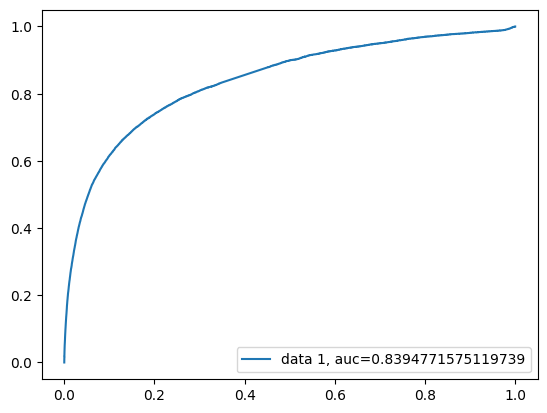

In [78]:
y_pred_proba = logreg.predict_proba(X_test)[::,1]
fpr, tpr, _ = metrics.roc_curve(y_test,  y_pred_proba)
auc = metrics.roc_auc_score(y_test, y_pred_proba)
plt.plot(fpr,tpr,label="data 1, auc="+str(auc))
plt.legend(loc=4)
plt.show()

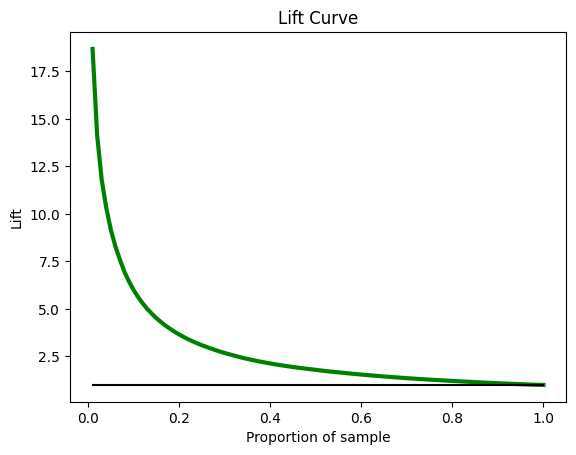

In [79]:
plot_lift_curve(y_test, y_pred_proba, step=0.01)

In [80]:
def lift_chart(X,actual_target,model):
    avg_tgt = actual_target.sum()/len(actual_target)
    df_data = X.copy()
    X_data = df_data.copy()
    df_data['Actual'] = actual_target
    df_data['Predict']= model.predict(X_data)
    y_Prob = pd.DataFrame(model.predict_proba(X_data))
    df_data['Prob_1']=list(y_Prob[1])
    df_data.sort_values(by=['Prob_1'],ascending=False,inplace=True)
    df_data.reset_index(drop=True,inplace=True)
    df_data['Percentile']=pd.qcut(df_data.index,100,labels=False)
    output_df = pd.DataFrame()
    grouped = df_data.groupby('Percentile',as_index=False)
    output_df['Max_Scr']=grouped.max().Prob_1
    output_df['Min_Scr']=grouped.min().Prob_1
    output_df['Actual']=grouped.sum().Actual
    output_df['Total']=grouped.count().Actual
    output_df["Population_perc"] = (output_df["Total"]/len(actual_target))*100
    output_df['Per_Events'] = (output_df['Actual']/output_df['Actual'].sum())*100
    output_df['Gain_Percentage'] = output_df.Per_Events.cumsum()
    output_df["Cumulative_Population"] = output_df.Population_perc.cumsum()
    output_df["Lift"] = output_df["Gain_Percentage"]/output_df["Cumulative_Population"]
    return output_df

In [81]:
lift_chart(X_test, y_test, logreg)

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,0.683809,0.171452,2135,7121,1.000006,18.68709,18.68709,1.000006,18.686985
1,0.171448,0.116509,1099,7121,1.000006,9.619256,28.306346,2.000011,14.153093
2,0.116509,0.090012,814,7121,1.000006,7.124726,35.431072,3.000017,11.810291
3,0.090010,0.073496,673,7121,1.000006,5.890591,41.321663,4.000022,10.330358
4,0.073495,0.061859,522,7121,1.000006,4.568928,45.890591,5.000028,9.178067
...,...,...,...,...,...,...,...,...,...
95,0.001479,0.001363,12,7121,1.000006,0.105033,98.722101,95.999978,1.028355
96,0.001363,0.001188,14,7121,1.000006,0.122538,98.844639,96.999983,1.019017
97,0.001188,0.000592,26,7121,1.000006,0.227571,99.07221,97.999989,1.010941
98,0.000592,0.000373,51,7121,1.000006,0.446389,99.5186,98.999994,1.005238


In [82]:
def lift_chart(X,actual_target,model):
    avg_tgt = actual_target.sum()/len(actual_target)
    df_data = X.copy()
    X_data = df_data.copy()
    df_data['Actual'] = actual_target
    df_data['Predict']= model.predict(X_data)
    y_Prob = pd.DataFrame(model.predict_proba(X_data))
    df_data['Prob_1']=list(y_Prob[1])
    df_data.sort_values(by=['Prob_1'],ascending=False,inplace=True)
    df_data.reset_index(drop=True,inplace=True)
    df_data['Decile']=pd.qcut(df_data.index,10,labels=False)
    output_df = pd.DataFrame()
    grouped = df_data.groupby('Decile',as_index=False)
    output_df['Max_Scr']=grouped.max().Prob_1
    output_df['Min_Scr']=grouped.min().Prob_1
    output_df['Actual']=grouped.sum().Actual
    output_df['Total']=grouped.count().Actual
    output_df["Population_perc"] = (output_df["Total"]/len(actual_target))*100
    output_df['Per_Events'] = (output_df['Actual']/output_df['Actual'].sum())*100
    output_df['Gain_Percentage'] = output_df.Per_Events.cumsum()
    output_df["Cumulative_Population"] = output_df.Population_perc.cumsum()
    output_df["Lift"] = output_df["Gain_Percentage"]/output_df["Cumulative_Population"]
    return output_df

In [83]:
lift_chart(X_test, y_test, logreg)

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,0.683809,0.034282,6856,71210,10.000056,60.008753,60.008753,10.000056,6.000842
1,0.034282,0.017371,1502,71210,10.000056,13.146608,73.155361,20.000112,3.657748
2,0.017371,0.011000,828,71209,9.999916,7.247265,80.402626,30.000028,2.680085
3,0.011000,0.008823,551,71210,10.000056,4.822757,85.225383,40.000084,2.13063
4,0.008823,0.007471,512,71209,9.999916,4.4814,89.706783,50.000000,1.794136
5,0.007471,0.005177,349,71210,10.000056,3.054705,92.761488,60.000056,1.546023
6,0.005177,0.003691,247,71209,9.999916,2.161926,94.923414,69.999972,1.356049
7,0.003691,0.002688,223,71210,10.000056,1.95186,96.875274,80.000028,1.21094
8,0.002688,0.001899,139,71209,9.999916,1.21663,98.091904,89.999944,1.089911
9,0.001899,0.000064,218,71210,10.000056,1.908096,100.0,100.000000,1.0


In [84]:
print(classification_report(y_test, y_predict_lab))

              precision    recall  f1-score   support

         0.0       0.98      1.00      0.99    700671
         1.0       0.42      0.07      0.11     11425

    accuracy                           0.98    712096
   macro avg       0.70      0.53      0.55    712096
weighted avg       0.98      0.98      0.98    712096



In [85]:
from sklearn.metrics import precision_recall_curve
precision, recall, thresholds = precision_recall_curve(y_test, y_predict_prob)
precision
recall
thresholds

array([6.39752673e-05, 6.52661436e-05, 6.54809136e-05, ...,
       6.57712345e-01, 6.62528077e-01, 6.83808653e-01])

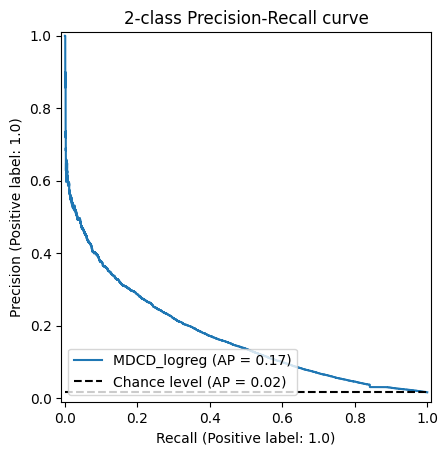

In [86]:
from sklearn.metrics import PrecisionRecallDisplay

display = PrecisionRecallDisplay.from_estimator(
    logreg_bsln, X_test, y_test, name="MDCD_logreg", plot_chance_level=True
)
_ = display.ax_.set_title("2-class Precision-Recall curve")

In [ ]:
plotting = pd.concat([kmdo_mem, mdcd_mem])

In [ ]:
# create a plot by category of the distribution of a given variable; x = categorical variable; y = continuous variable
sns.histplot(data=plotting, x='emb0', hue='embed_type', palette='Set3')#, ax=axes[0, 0])
plt.ylim(0, 20000)

(0.0, 20000.0)

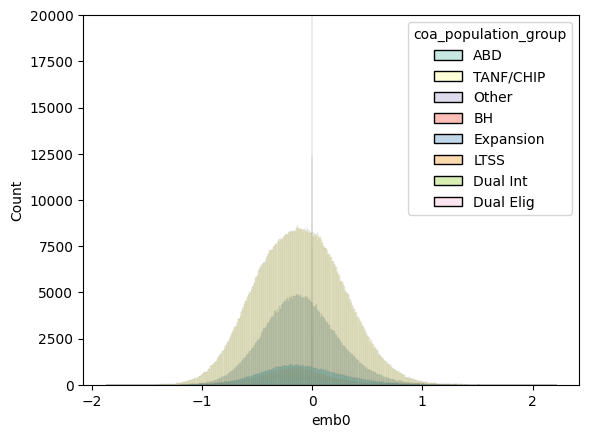

In [23]:
sns.histplot(data=kmdo_mem, x='emb0', hue='coa_population_group', palette='Set3')#, ax=axes[0, 0])
plt.ylim(0, 20000)

(0.0, 20000.0)

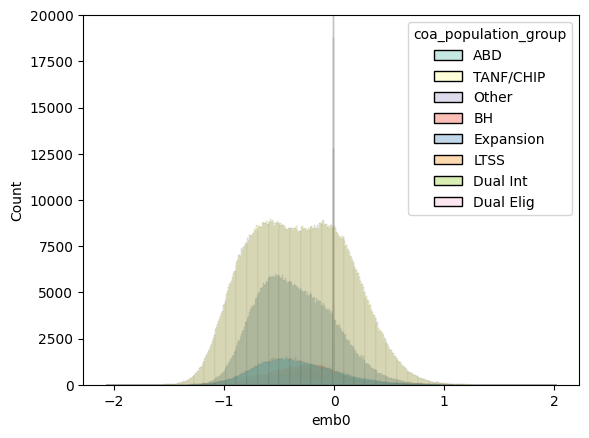

In [24]:
sns.histplot(data=mdcd_mem, x='emb0', hue='coa_population_group', palette='Set3')#, ax=axes[0, 0])
plt.ylim(0, 20000)

(0.0, 20000.0)

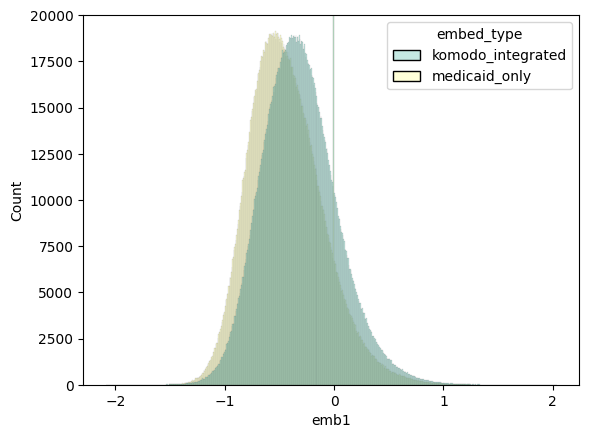

In [25]:
# create a plot by category of the distribution of a given variable; x = categorical variable; y = continuous variable
sns.histplot(data=plotting, x='emb1', hue='embed_type', palette='Set3')#, ax=axes[0, 0])
plt.ylim(0, 20000)

(0.0, 20000.0)

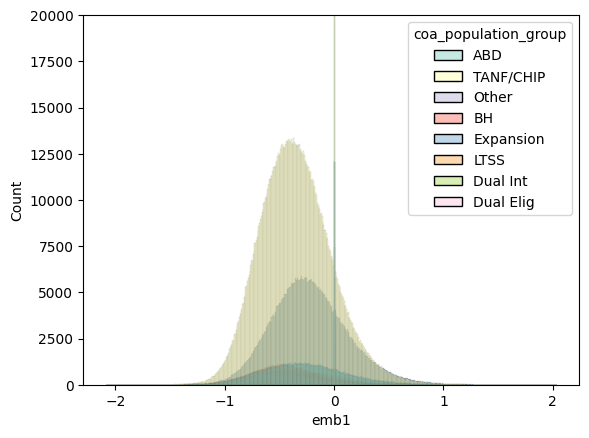

In [27]:
sns.histplot(data=kmdo_mem, x='emb1', hue='coa_population_group', palette='Set3')#, ax=axes[0, 0])
plt.ylim(0, 20000)

(0.0, 20000.0)

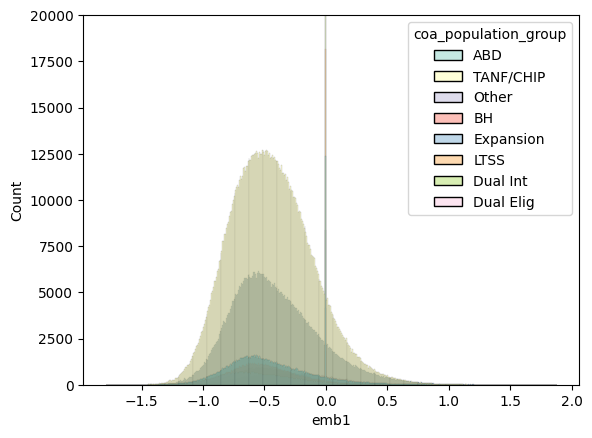

In [28]:
sns.histplot(data=mdcd_mem, x='emb1', hue='coa_population_group', palette='Set3')#, ax=axes[0, 0])
plt.ylim(0, 20000)

In [ ]:
# create the data, or the data that is to be estimated
data = data.drop('TOTAL_DAYS_TO_COMPLETE', axis=1)

# Remove the order number since we don't need it
order_numbers = data['ORDER_NUMBER']
data = data.drop('ORDER_NUMBER', axis=1)

# # split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(data, label, test_size = 0.2)

rf = RandomForestRegressor(
    bootstrap = True,
    max_depth = None,
    max_features = 'sqrt',
    min_samples_leaf = 1,
    min_samples_split = 2,
    n_estimators  = 5000
)
rf.fit(X_train, y_train)
rf_predictions = rf.predict(X_test)
rf_differences = compare_values(y_test, rf_predictions)
rf_Avg = np.average(rf_differences)
print("#################################################")
print("DATA FOR RANDOM FORESTS")
print(rf_Avg)
importances = get_feature_importances(X_test.columns, rf.feature_importances_)
print()
print(importances)

res = y_test.to_frame('Actual Value')
res.insert(0, 'Predicted Value', rf_predictions)
res = order_numbers.to_frame().join(res, how='inner')
print(res)